# Multi armed bandits

Jorge Alejandro, _a20202060@pucp.edu.pe_

**References:**
- [Reinforcement Learning: An Introduction (Sutton & Barto, 2018)](http://incompleteideas.net/book/the-book-2nd.html)

---

# Setup

In [11]:
import numpy as np
import random

import plotting.bandits

# The k-armed bandits problem

The problem consists on $k$ arms that can each be pulled to obtain an independent reward. Each reward corresponding to a particular arm is given based on sampling a normal distribution.

For example, we have $k=10$ arms being used as testbed, we generate 10 means based on a normal distribution with $μ=0.0$ and $σ=1.0$. Then, each arm normal distribution is based on said generated mean and $σ=1.0$. We can see this in the following code and plot

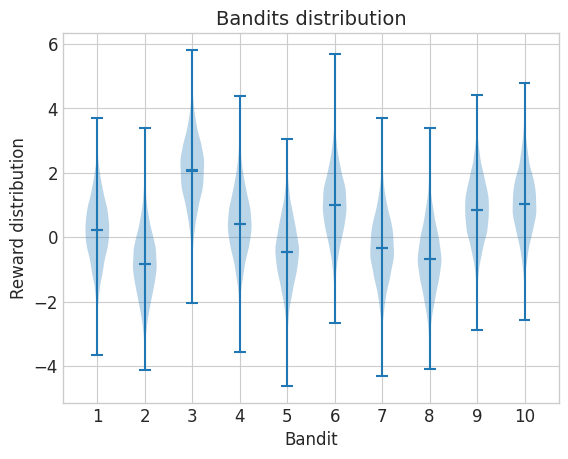

In [12]:
k = 10
bandit_means = np.random.normal(loc=0.0, scale=1.0, size=k)
optimal_bandit = np.argmax(bandit_means)

plotting.bandits.plot_bandits(bandit_means)

We can see the means are normally distributed as we previously described.

# A simple bandit algorithm

An approach mentioned in Sutton & Barto book for obtaining the highest amount of reward over time consists on guessing how much reward would each arm give when pulled (we'll call these $Q$-values of each arm $a$) and pulling the higher expected reward one. This would be a greedy approach of choosing which arm ($A$) to pull:

$$
    A ← argmax_a Q(a)
$$

This approach is flawed given the stochastic nature of the k-armed bandit problem. If we followed this approach there are high chances we would get stuck at a fake optimum. This is the **exploration vs exploitation** dilemma, a common topic in reinforcement learning.

To solve this lack of exploration problem, we use the following exploration strategy to pull the arms in a way we guarantee a minimum amount of **exploration** to discover better solutions while still preferring to **exploit** the best known arm to pull. This is called the ϵ-greedy approach:

$$
    A ←
    \begin{cases}
    \text{argmax}_a Q(a) & \text{with probability }  1-ϵ \\
    \text{a random action} & \text{with probability }  ϵ
    \end{cases}
$$

Now, each guess should be base on the data we gather while interacting with the environment, an usual good estimator for a value would be the following:

$$
    Q_{t}(a) = \frac{\sum_{i=1}^{t-1} R_i \mathbf{1}_{A_i=a}}{\sum_{i=1}^{t-1} \mathbf{1}_{A_i=a}}
$$

where $N(a)$ represents the amount of times the arm $a$ has been pulled, $\mathbf{1}_{condition}$ is 1 when condition is true and 0 when it's false.

If we transform this average into an iterative / incremental form we would get the following update rule:

$$
    Q(a) ← Q(a) + \frac{1}{N(A)} [R - Q(a)]
$$

If we combine all this together we get the following algorithm for solving (getting the highest reward over time) the k-armed bandit problem. 

**Pseudocode**:

$$
    \begin{aligned}
    & \textbf{Initialize:} \quad Q(a) ← 0, \; N(a) ← 0 \quad ∀ a \\
    & \textbf{Repeat:} \\
    & \quad A ←
        \begin{cases} 
        \text{argmax}_a Q(a) & \text{prob } 1-ϵ \\ 
        \text{random action} & \text{prob } ϵ 
        \end{cases} \\
    & \quad R ← \text{bandit}(A) \\
    & \quad N(A) ← N(A) + 1 \\
    & \quad Q(A) ← Q(A) + \frac{1}{N(A)} [R - Q(A)]
    \end{aligned}
$$

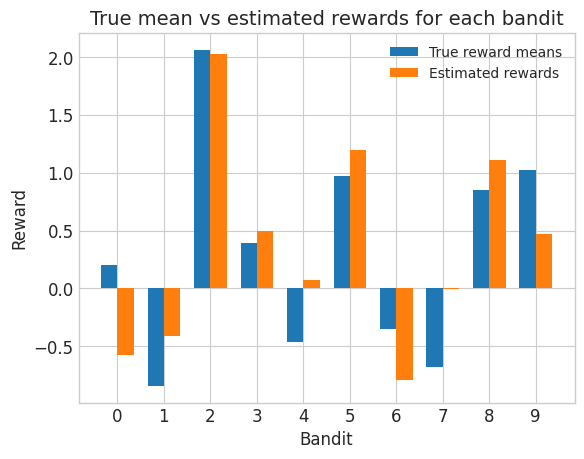

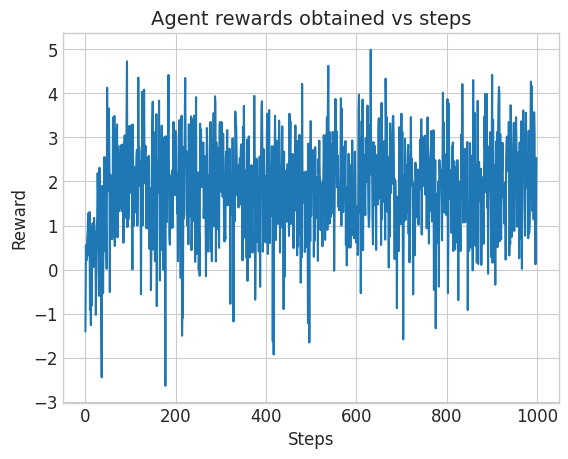

In [13]:
def simple_bandit_algorithm(
    bandit_means, bandit_sds, k, epsilon, steps
):
    Q = np.zeros(k)
    N = np.zeros(k)

    # Metrics
    R = np.empty(steps)
    opt_action = np.full(steps, False)

    for step in range(steps):
        A = np.argmax(Q) if random.random() > epsilon else random.randint(0,k-1)

        reward = np.random.normal(loc=bandit_means[A], scale=bandit_sds[A], size=None)

        N[A] = N[A] + 1
        Q[A] = Q[A] + (1/N[A]) * (reward - Q[A])

        # Metrics
        opt_action[step] = A == optimal_bandit
        R[step] = reward

    return Q, R, opt_action

estimated_bandit_rewards, rewards, optimal_actions = simple_bandit_algorithm(
    bandit_means=bandit_means,
    bandit_sds=np.full(k,1.0),
    epsilon=0.1,
    steps=1000,
    k=k
)

plotting.bandits.plot_bandits_true_vs_estimated_reward(estimated_bandit_rewards, bandit_means)
plotting.bandits.plot_bandit_rewards(rewards)

We can see from the first plot we reach a mostly accurate estimation ($Q$-values) of each arm value (converges to the true mean of each arm)

We can also see the rewards obtained through 1000 steps, which is very noisy given the normal distribution of each arm

## Experimentation

We test this simple bandit algorithm for multiple values of $ϵ$ with 2000 samples of 2000 steps each:
- $ϵ=0.1$, this would be our standard baseline
- $ϵ=0.01$, this would be an exploitation-tuned algorithm
- $ϵ=0.0$, this would be the **greedy** approach discussed early
- $ϵ=1.0$, this would be purely exploration, a random **policy**

Samples are run and then the following data is plotted:
- Average reward per step
- Average % of optimal actions

In [14]:
sample_size = 2000

default_params = {
    "bandit_means": bandit_means,
    "bandit_sds": np.full(k, 1.0),
    "steps": 2000,
    "k": k,
}

greedy_bandits_res = [
    simple_bandit_algorithm(
        **(default_params | {"epsilon": 0.0})
    ) for _ in range(sample_size)
]

low_eps_bandits_res = [
    simple_bandit_algorithm(
        **(default_params | {"epsilon": 0.01})
    ) for _ in range(sample_size)
]

std_bandits_res = [
    simple_bandit_algorithm(
        **(default_params | {"epsilon": 0.1})
    ) for _ in range(sample_size)
]

random_bandits_res = [
    simple_bandit_algorithm(
        **(default_params | {"epsilon": 1.0})
    ) for _ in range(sample_size)
]

rewards_std = np.mean(np.array([res[1] for res in std_bandits_res]), axis=0)
rewards_low_eps = np.mean(np.array([res[1] for res in low_eps_bandits_res]), axis=0) 
rewards_greedy = np.mean(np.array([res[1] for res in greedy_bandits_res]), axis=0)
rewards_random = np.mean(np.array([res[1] for res in random_bandits_res]), axis=0)

opt_act_std = np.mean(np.array([res[2] for res in std_bandits_res]), axis=0)
opt_act_low_eps = np.mean(np.array([res[2] for res in low_eps_bandits_res]), axis=0)
opt_act_greedy = np.mean(np.array([res[2] for res in greedy_bandits_res]), axis=0)
opt_act_random = np.mean(np.array([res[2] for res in random_bandits_res]), axis=0)

## Results and analysis

We get the following plots based on the previous experiments

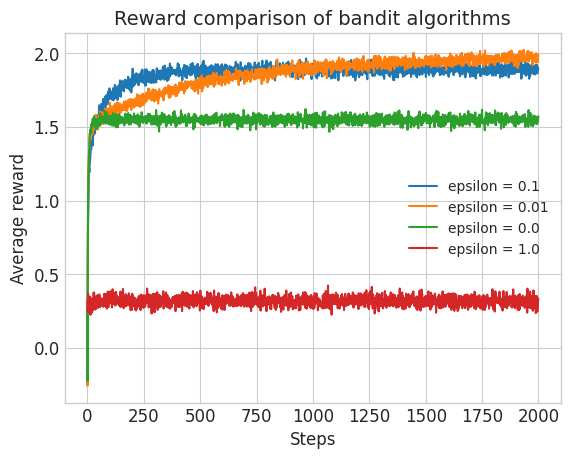

In [15]:
plotting.bandits.plot_bandit_rewards_comparison([
    (rewards_std, "epsilon = 0.1"),
    (rewards_low_eps, "epsilon = 0.01"),
    (rewards_greedy, "epsilon = 0.0"),
    (rewards_random, "epsilon = 1.0"),
])

From this plot we can see...

- The fully exploratory approach ($ϵ=1.0$) is the worst performing with significant difference given it's not optimizing anything, just acting randomly.

- The fully greedy approach ($ϵ=0.0$) has a lower upper bound than the other approaches given it usually gets stuck at local optima and can't converge to optimal behavior.

- The lower $ϵ$ approach converges slower but to a higher value than the higher $ϵ$ approach. This is because the higher $ϵ$ approach is limited by having to use $10\%$ of its actions on exploratory moves while this ratio is of $1\%$ for the other approach.

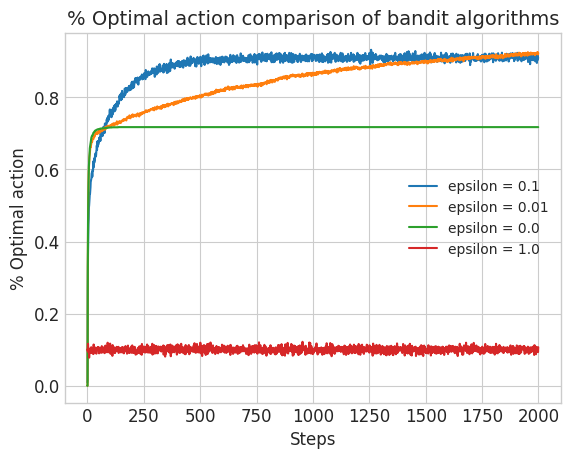

In [16]:
plotting.bandits.plot_bandit_opt_act_comparison([
    (opt_act_std, "epsilon = 0.1"),
    (opt_act_low_eps, "epsilon = 0.01"),
    (opt_act_greedy, "epsilon = 0.0"),
    (opt_act_random, "epsilon = 1.0"),
])

From this plot we can see...

- The fully exploratory approach has a consistent $10\%$ chance of getting the right option given there's $k=10$ arms.

- The fully greedy approach seems to get stuck at local optima so in a lot of these experiments it won't get to the optimal action.

- The lower $ϵ$ approach seems to converge slower but to a higher chance of getting the optimal value consistently than the higher $ϵ$ approach. This can be explained given the higher $ϵ$ approach has an upperbound of $90\%$ given its epsilon. We can assume the lower $ϵ$ approach will eventually reach an upperbound of $99\%$ 

# Optimistic initial values

We can improve the convergence time of our simple bandit algorithm by applying a trick in the initialization of the $Q$-values.

If we initialize with high values (relative to the testbed values) then we guarantee exploration given the algorithm will follow this pattern:

- Agent sees a high $Q$-value and pulls the lever.
- It gets a much lower result than expected, it gets "disappointed" on said arm.
- Next action it sees another high $Q$-value (different from the previous one)
- This pattern gets repeated

Although we're usually accelerating convergence time (measured in steps), we're introducing certain bias to our estimates, given the $Q$s no longer represent the average of returned values.

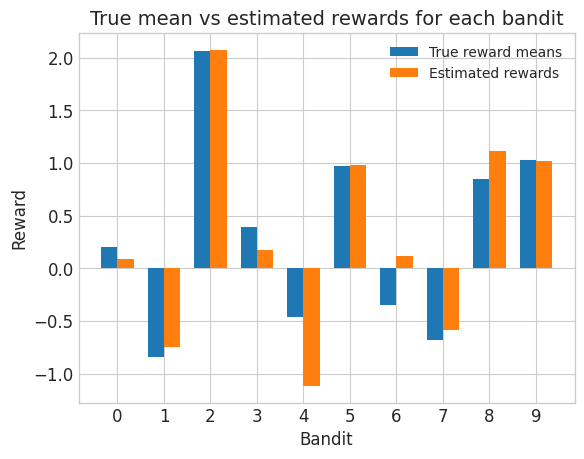

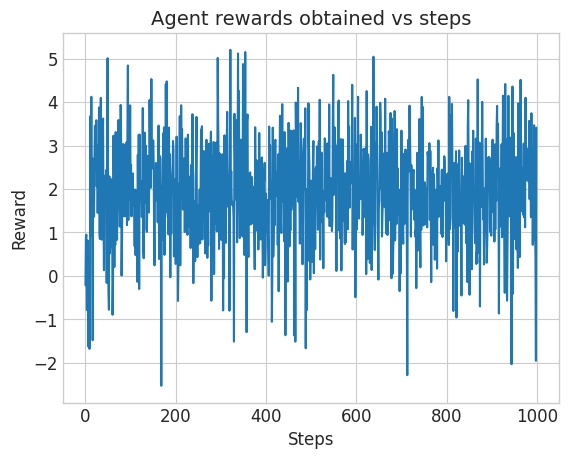

In [ ]:
def optimistic_initial_values_bandit_algorithm(
    bandit_means, bandit_sds, k, epsilon, steps, initial_value
):
    Q = np.full(k, initial_value) # Only real change
    N = np.zeros(k)

    # Metrics
    R = np.empty(steps)
    opt_action = np.full(steps, False)

    for step in range(steps):
        A = np.argmax(Q) if random.random() > epsilon else random.randint(0,k-1)

        reward = np.random.normal(loc=bandit_means[A], scale=bandit_sds[A], size=None)

        N[A] = N[A] + 1
        Q[A] = Q[A] + (1/N[A]) * (reward - Q[A])

        # Metrics
        opt_action[step] = A == optimal_bandit
        R[step] = reward

    return Q, R, opt_action

estimated_bandit_rewards, rewards, optimal_actions = optimistic_initial_values_bandit_algorithm(
    bandit_means=bandit_means,
    bandit_sds=np.full(k,1.0),
    epsilon=0.1,
    steps=1000,
    k=k,
    initial_value=10.0 # high relative to the testbed
)

plotting.bandits.plot_bandits_true_vs_estimated_reward(estimated_bandit_rewards, bandit_means)
plotting.bandits.plot_bandit_rewards(rewards)

## Experimentation

We'll now compare the following approaches on the same conditions as the previous comparison (2000 experiments and 2000 steps):
- $ϵ=0.1$ without OIV (optimistic initial values), this would be our standard baseline
- $ϵ=0.0$ without OIV, this would be our greedy baseline
- $ϵ=0.1$ with OIV, this would be applying OIV to our baseline
- $ϵ=0.0$ with OIV, this would be a purely greedy OIV approach

Samples are run and then the following data is plotted:
- Average reward per step
- Average % of optimal actions

In [23]:
std_optimistic_bandit_res = [
    optimistic_initial_values_bandit_algorithm(
        **(default_params | {"epsilon": 0.1, "initial_value": 10.0})
    ) for _ in range(sample_size)
]

greedy_optimistic_bandits_res = [
    optimistic_initial_values_bandit_algorithm(
        **(default_params | {"epsilon": 0.0, "initial_value": 10.0})
    ) for _ in range(sample_size)
]

rewards_std_optimistic = np.mean(np.array([res[1] for res in std_optimistic_bandit_res]), axis=0)
rewards_greedy_optimistic = np.mean(np.array([res[1] for res in greedy_optimistic_bandits_res]), axis=0)

opt_act_std_optimistic = np.mean(np.array([res[2] for res in std_optimistic_bandit_res]), axis=0)
opt_act_greedy_optimistic = np.mean(np.array([res[2] for res in greedy_optimistic_bandits_res]), axis=0)

## Results and analysis

We get the following plots based on the previous experiments

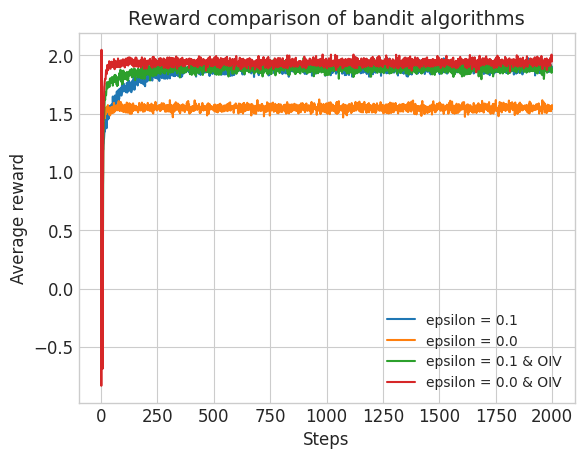

In [24]:
plotting.bandits.plot_bandit_rewards_comparison([
    (rewards_std, "epsilon = 0.1"),
    (rewards_greedy, "epsilon = 0.0"),
    (rewards_std_optimistic, "epsilon = 0.1 & OIV"),
    (rewards_greedy_optimistic, "epsilon = 0.0 & OIV"),
])

From this plot we can see...

- Again, we see the purely greedy approach gets stuck in local optima.

- The fastest algorithm to converge is the purely greedy one with optimistic initial values given it lacks the obligation to expend $10\%$ of its actions exploring but doesn't get stuck like the no-OIV approach because there's implicit exploration given the dynamic described previously.

- The purely greedy OIV approach has higher rewards than the $ϵ$-greedy with OIV approach for the same reason above.

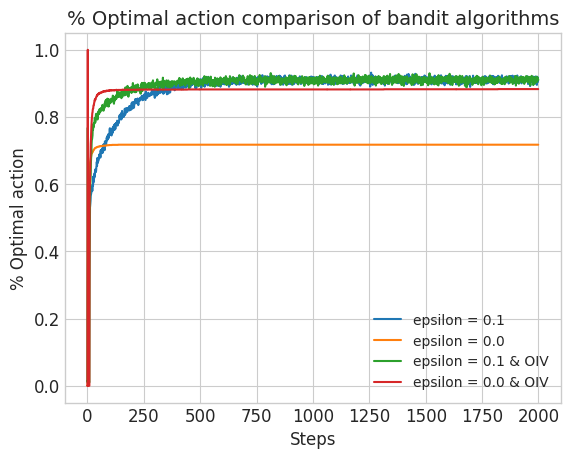

In [ ]:
plotting.bandits.plot_bandit_opt_act_comparison([
    (opt_act_std, "epsilon = 0.1"),
    (opt_act_greedy, "epsilon = 0.0"),
    (opt_act_std_optimistic, "epsilon = 0.1 & OIV"),
    (opt_act_greedy_optimistic, "epsilon = 0.0 & OIV"),
])

From this plot we can see...

- Again, the purely greedy without OIV approach gets stuck and can't consistently get to optimal actions.

- The greedy OIV has lower % of optimal action given it's still a greedy approach and can get stuck, although rarely and this is reflected on its upperbound compared to the $ϵ$-greedy OIV and no-OIV approaches which will eventually get unstuck of local optima.

From this analyzed data we can see OIV certainly helps converge faster but is not a real replacement for more robust exploratory measures.

# Upper Confidence Bound

While $ϵ$-greedy is an intuitive and simple approach to handle exploration, it introduces an upperbound of performance (reward obtained) to the algorithm given its obligation to explore $ϵ\%$ of the time. Although this can be mitigated with decaying $ϵ$ approaches. We'll introduce an alternative.

We can, instead of mandatory random exploration, quantify and parametrize how much appealing a bandit is for the agent at determined time-step and make it choose the one with higher score. For this we'll need to evaluate each action with a function that balances exploration and exploitation. This approach is called upper-confidence bound.

The described function can take this form:

$$
    A_t \leftarrow \text{argmax}_a \left[ Q(a) + c \sqrt{\frac{\ln t}{N(a)}} \right]
$$

Where c is a parameter which determines how important is exploration for this evaluating function.

We make some adaptations to ensure this function can handle possible division by zero and is more computationally stable:

$$
    A_t \leftarrow \text{argmax}_a \left[ Q(a) + c \sqrt{\frac{\ln{(t + 1)}}{N(a) + 1}} \right]
$$

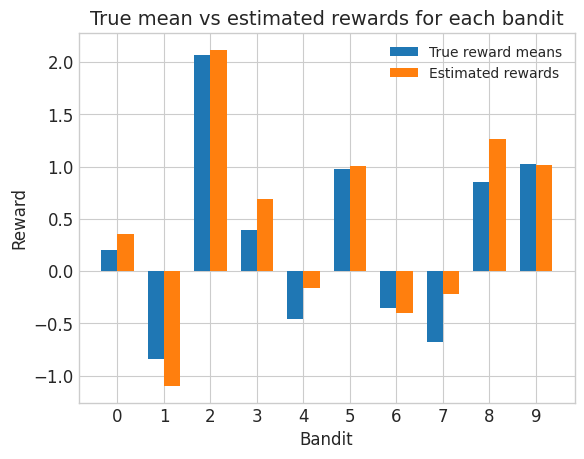

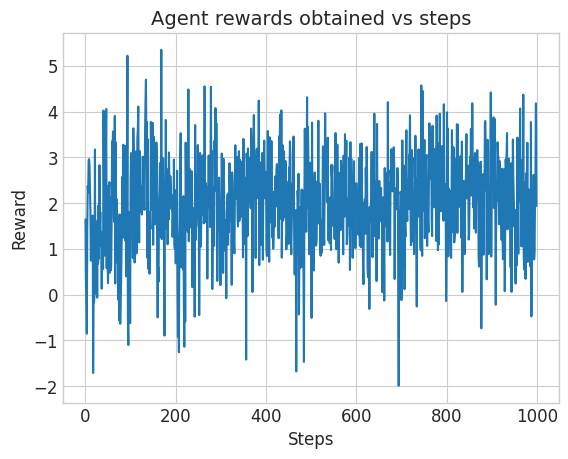

In [19]:
def ucb_bandit_algorithm(
    bandit_means, bandit_sds, k, steps, c
):
    Q = np.zeros(k)
    N = np.zeros(k)

    # Metrics
    R = np.empty(steps)
    opt_action = np.full(steps, False)

    for step in range(steps):
        # Some minor offsets to not divide by zero
        ucb_values = [Q[a] + c * np.sqrt(np.log(step + 1) / (N[a] + 1)) for a in range(k)]
        A = np.argmax(ucb_values)

        reward = np.random.normal(loc=bandit_means[A], scale=bandit_sds[A], size=None)

        N[A] = N[A] + 1
        Q[A] = Q[A] + (1/N[A]) * (reward - Q[A])

        # Metrics
        opt_action[step] = A == optimal_bandit
        R[step] = reward

    return Q, R, opt_action

estimated_bandit_rewards, rewards, optimal_actions = ucb_bandit_algorithm(
    bandit_means=bandit_means,
    bandit_sds=np.full(k,1.0),
    steps=1000,
    k=k,
    c=2
)

plotting.bandits.plot_bandits_true_vs_estimated_reward(estimated_bandit_rewards, bandit_means)
plotting.bandits.plot_bandit_rewards(rewards)

## Experimentation

We'll now compare the following approaches on the same conditions as the previous comparison (2000 experiments and 2000 steps):
- $ϵ=0.1$ $ϵ$-greedy, our standard baseline
- $c=2.0$ UCB, the approach we're comparing against

Samples are run and then the following data is plotted:
- Average reward per step
- Average % of optimal actions

In [27]:
ucb_bandits_res = [
    ucb_bandit_algorithm(
        **(default_params | {"c": 2})
    ) for _ in range(sample_size)
]

rewards_ucb = np.mean(np.array([res[1] for res in ucb_bandits_res]), axis=0)

opt_act_ucb = np.mean(np.array([res[2] for res in ucb_bandits_res]), axis=0)

## Results and analysis

We get the following plots based on the previous experiments

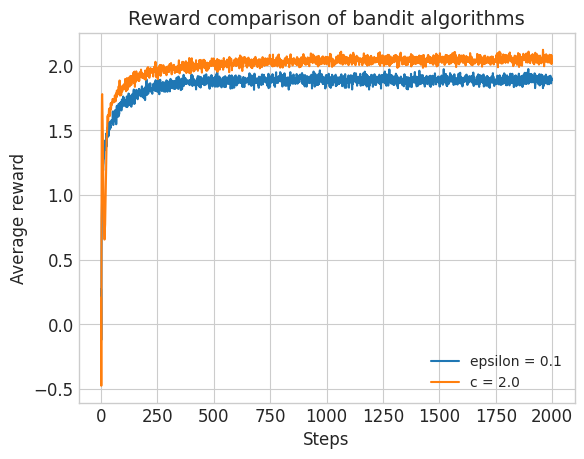

In [28]:
plotting.bandits.plot_bandit_rewards_comparison([
    (rewards_std, "epsilon = 0.1"),
    (rewards_ucb, "c = 2.0"),
])

From this plot we can see...

- Clearly the UCB approach dominates the $ϵ$-greedy approach, it converges faster and to a higher value. It lacks the mandatory exploration that limits the simpler $ϵ$-greedy approach.

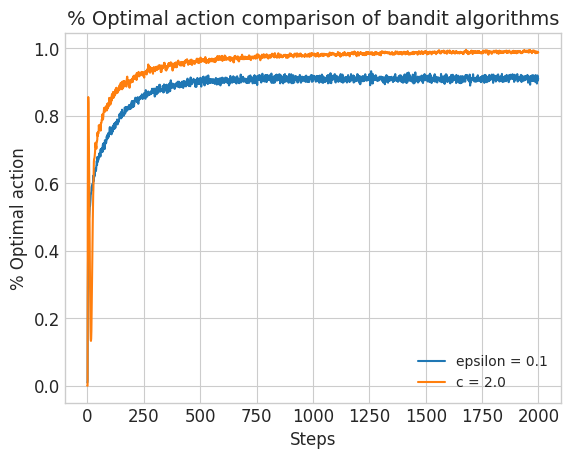

In [29]:
plotting.bandits.plot_bandit_opt_act_comparison([
    (opt_act_std, "epsilon = 0.1"),
    (opt_act_ucb, "c = 2.0"),
])

From this plot we can see...

- The UCB approach converges to 100% optimal actions while our $ϵ$-greedy approach converges to only $90\%$ given its mandatory exploration.

Although it may seem UCB is the best solution based on this results, it certainly is harder to implement in more complex environments (stateful ones for example), so we'll keep seeing the $ϵ$-greedy approaches.